# Simulation based inference on the trajectories for the 2D parameter space

I use my own `conda` environment with `torch` and `lampe`. Data is downloaded from Zenodo and stored in the `data` directory. The data is not included in the repository, but can be downloaded from the Zenodo link provided in the README.

In [1]:
import lampe
from tqdm import tqdm

## Read training data

I use the information in the `lampe` tutorial about data and simulators: [https://lampe.readthedocs.io/stable/tutorials/simulators.html](https://lampe.readthedocs.io/stable/tutorials/simulators.html)

In [13]:
import numpy as np

# Load data from numpy files
params = np.load('../data/training-trajectories/2D-delta-omega/param_rand_list-2D.npy')
taus = np.load('../data/training-trajectories/2D-delta-omega/taus-2D.npy')


The `params` have been generated from a uniform prior distribution and the `taus` are generated by a simulator that solves the Master Equation of the TLS and returns single trajectories with jumps.

In [14]:
print(f"We have {len(params)} trajectories")

We have 4000000 trajectories


In [15]:
params.shape

(4000000, 2)

In [199]:
params.max(axis=0), params.min(axis=0)

(array([2.99999929, 4.99999964]), array([5.95611374e-07, 2.50000203e-01]))

### Plot samples from the training data

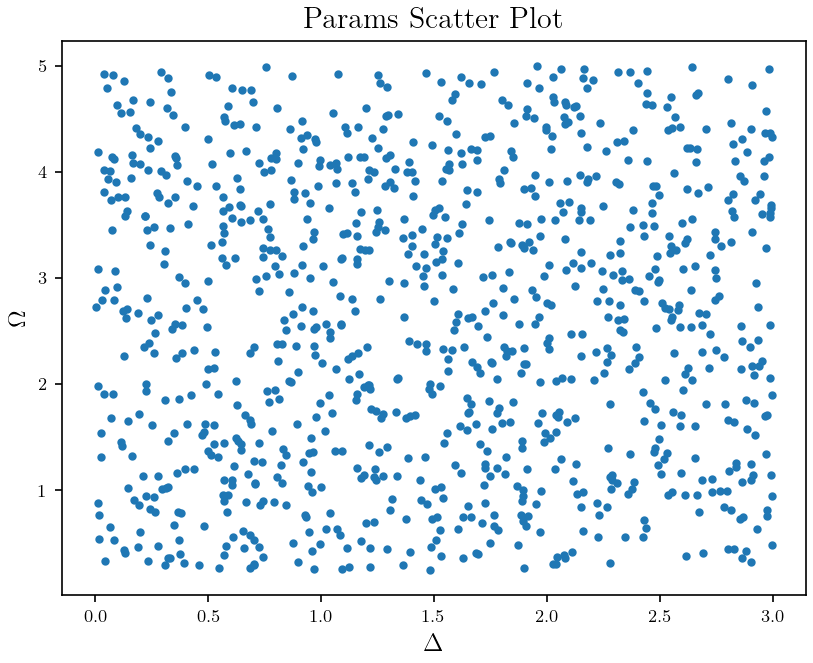

In [66]:
import matplotlib.pyplot as plt
from lampe.plots import nice_rc

plt.rcParams.update(nice_rc(latex=True))  # nicer plot settings


params_2d = params[:1000]  # Select the first 1000 points

LABELS = [r'$\Delta$', r'$\Omega$']
plt.scatter(params_2d[:, 0], params_2d[:, 1])
plt.xlabel(LABELS[0])
plt.ylabel(LABELS[1])
plt.title('Params Scatter Plot')
plt.show()

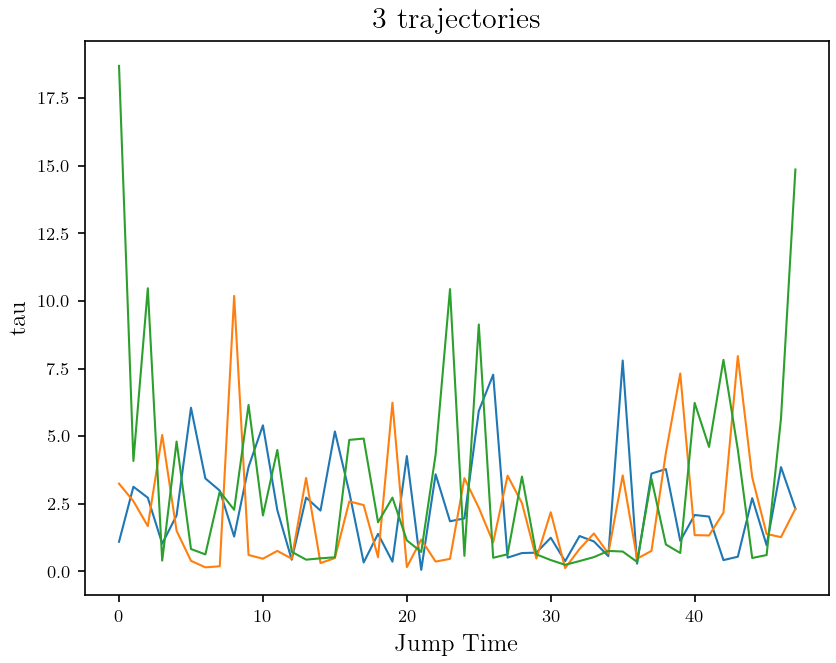

In [72]:
# Select 3 elements from taus
elements = taus[:3]

# Plot the elements as lines
for element in elements:
    plt.plot(element)

# Add labels and title
plt.xlabel('Jump Time')
plt.ylabel('tau')
plt.title('3 trajectories')

# Show the plot
plt.show()

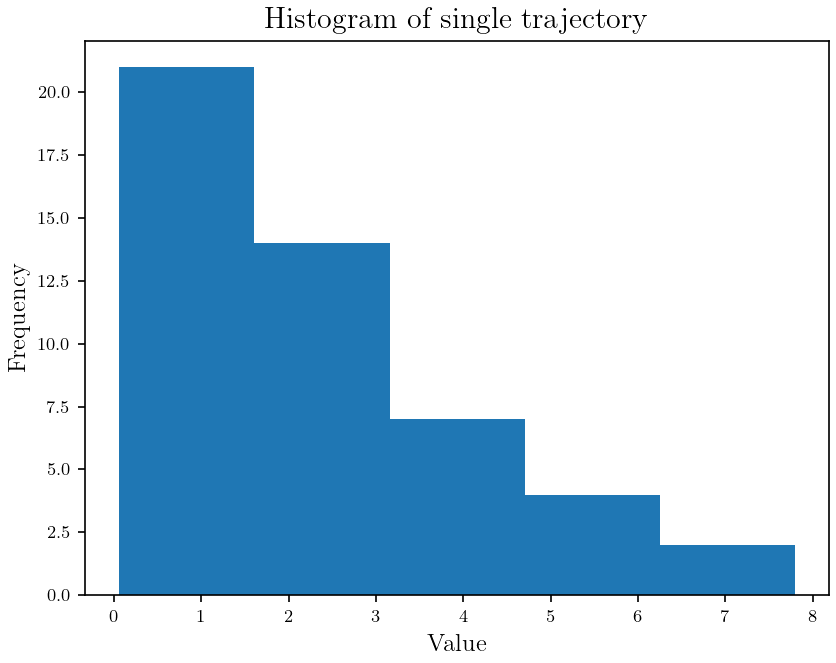

In [70]:
element_index = 0  # Index of the element in taus
element = taus[element_index]  # Get the element from taus

plt.hist(element, bins=5)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of single trajectory')
plt.show()

### Save training data in HDF5

We can save the training data in a HDF5 file for convenience. We use the `lampe.data.H5Dataset` class to store the data

In [160]:
pairs = []
batch_size = 512
batch_num = 1000  # test on just 1000 batches
training_size = batch_size*batch_num

for i in range(batch_num):
    theta = params[i*batch_size:(i+1)*batch_size]
    x = taus[i*batch_size:(i+1)*batch_size]

    pairs.append((theta, x))

lampe.data.H5Dataset.store(pairs, "../data/training-trajectories/2D-delta-omega/data_bs512_bn1000.h5", size=training_size)
# lampe.data.H5Dataset.store(pairs, "../data/training-trajectories/2D-delta-omega/data_bs512_bn100.h5", size=training_size)

  0%|          | 0/51200 [00:00<?, ?pair/s]


The saved data can be loaded using the `lampe.data.H5Dataset` class.

In [17]:
dataset = lampe.data.H5Dataset(
    "../data/training-trajectories/2D-delta-omega/data_bs512_bn1000.h5"
)

In [18]:
for theta, x in tqdm(dataset):
    pass

100%|██████████| 512000/512000 [00:02<00:00, 246360.56it/s]


Can batch and shuffle

In [19]:
dataset = lampe.data.H5Dataset(
    "../data/training-trajectories/2D-delta-omega/data_bs512_bn1000.h5",
    batch_size=4,
    shuffle=True,
)

In [20]:
for theta, x in dataset:
    print(theta, x, sep="\n")
    break

tensor([[2.3165, 1.4247],
        [2.1748, 0.4196],
        [1.1790, 1.9139],
        [2.6648, 4.5129]])
tensor([[ 0.8448,  7.7672,  1.4842,  2.0511,  0.6310,  1.0969,  0.3215,  2.0967,
          2.1123,  0.8325,  0.3472,  1.0268,  5.2264,  0.5361,  0.7962,  3.9089,
          0.2453,  0.7965,  2.9339,  0.5270,  2.1813, 13.8362,  0.6326,  7.6198,
          5.9897,  4.3091, 11.8323,  3.1943,  1.4028,  0.9067,  1.2204,  0.2917,
          0.3792,  5.8998,  7.2342,  2.6146,  0.5027, 14.8837,  5.8206,  1.0191,
          0.8182,  9.8859,  2.1853,  2.4798,  0.4147,  0.3145,  4.0731,  4.8064],
        [ 4.9519, 30.5859,  8.8833, 33.1919, 55.4896, 68.2288, 22.0889, 61.5484,
         14.5012, 39.9060, 11.6391, 36.1273, 28.6280, 24.0600, 14.2459, 99.8895,
          3.3961, 28.9693, 46.1978, 19.6244,  7.4502, 21.2540, 31.1112, 45.2022,
         20.4902,  7.5647,  5.1424, 20.9375,  5.3178, 16.2526, 13.7885, 32.8369,
          5.5690, 21.7863, 36.0042,  4.0137,  1.3316, 10.4478,  5.9273, 24.6332,
   

## Train NPE

For training, we shuffle the data and use a batch size of 256. We also load everything in memory for simplicity.

In [54]:
dataset = lampe.data.H5Dataset(
    "../data/training-trajectories/2D-delta-omega/data_bs512_bn1000.h5", batch_size=256, shuffle=True
).to_memory()

In [161]:
valid_dataset = lampe.data.H5Dataset(
    "../data/training-trajectories/2D-delta-omega/data_bs512_bn100.h5",
    batch_size=256,
    shuffle=False,
).to_memory()

Training a NPE model is done by following this tutorial on the `lampe` documentation: [https://lampe.readthedocs.io/stable/tutorials/npe.html#training](https://lampe.readthedocs.io/stable/tutorials/npe.html#training)

In [27]:
import torch
import torch.optim as optim
import zuko

from itertools import islice
from lampe.inference import NPE, NPELoss
from lampe.plots import corner, mark_point
from lampe.utils import GDStep
from tqdm import trange

In [209]:
# shape of parameters and trajectories
theta_dim = params.shape[-1]
x_dim = taus.shape[-1]

# create estimator object for the posterior
estimator = NPE(theta_dim=theta_dim, x_dim=x_dim, transforms=3, hidden_features=[128] * 3)
estimator

NPE(
  (flow): MAF(
    (transform): LazyComposedTransform(
      (0): MaskedAutoregressiveTransform(
        (base): MonotonicAffineTransform()
        (order): [0, 1]
        (hyper): MaskedMLP(
          (0): MaskedLinear(in_features=50, out_features=128, bias=True)
          (1): ReLU()
          (2): MaskedLinear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): MaskedLinear(in_features=128, out_features=128, bias=True)
          (5): ReLU()
          (6): MaskedLinear(in_features=128, out_features=4, bias=True)
        )
      )
      (1): MaskedAutoregressiveTransform(
        (base): MonotonicAffineTransform()
        (order): [1, 0]
        (hyper): MaskedMLP(
          (0): MaskedLinear(in_features=50, out_features=128, bias=True)
          (1): ReLU()
          (2): MaskedLinear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): MaskedLinear(in_features=128, out_features=128, bias=True)
          (5): ReLU()
  

In [210]:
estimator(torch.randn(1, theta_dim), torch.randn(1, x_dim))

tensor([-3.1316], grad_fn=<AddBackward0>)

The default builder for the NPE is a Masked Autoregressive Flow (MAF)

In the case of NPE, the loss to minimize is the expected negative log-likelihood of the data 

In [211]:
loss = NPELoss(estimator)

In [212]:
loss(*dataset[0])

tensor(12.7252, grad_fn=<NegBackward0>)

Training loop. To improve training we preprocess the parameters (`theta`) so that their mean and variances are 0 and 1 respectively.

In [207]:
LOWER = torch.tensor(params.min(axis=0), dtype=torch.float32)
UPPER = torch.tensor(params.max(axis=0), dtype=torch.float32)

def preprocess(theta: torch.Tensor) -> torch.Tensor:
    return 2 * (theta - LOWER) / (UPPER - LOWER) - 1


def postprocess(theta: torch.Tensor) -> torch.Tensor:
    return (theta + 1) / 2 * (UPPER - LOWER) + LOWER

In [214]:
optimizer = optim.Adam(estimator.parameters(), lr=1e-3)
step = GDStep(optimizer, clip=1.0)  # gradient descent step with gradient clipping

estimator.train()

for epoch in (bar := trange(50, unit="epoch")):
    losses, val_losses = [], []

    for theta, x in dataset:
        losses.append(step(loss(preprocess(theta), x)))

    for theta, x in valid_dataset:
        val_losses.append(loss(preprocess(theta), x))

    bar.set_postfix(
        loss=torch.stack(losses).mean().item(),
        val_loss=torch.stack(val_losses).mean().item(),
    )

100%|██████████| 50/50 [05:33<00:00,  6.66s/epoch, loss=-.346, val_loss=360] 


## Quick evaluation

We take a datapoint from the training data that has not actually been used for training (it was not saved on the HDF5 file) and evaluate the NPE model on it.

In [215]:
theta_star = torch.tensor(params[1_000_000], dtype=torch.float32)
x_star = torch.tensor(taus[1_000_000], dtype=torch.float32)

Sample from the posterior. It is a flow-based model, and we condition it on the observation `x_star`

In [217]:
estimator.eval()

with torch.no_grad():
    samples = estimator.flow(x_star).sample((2**16,))
    samples = postprocess(samples)

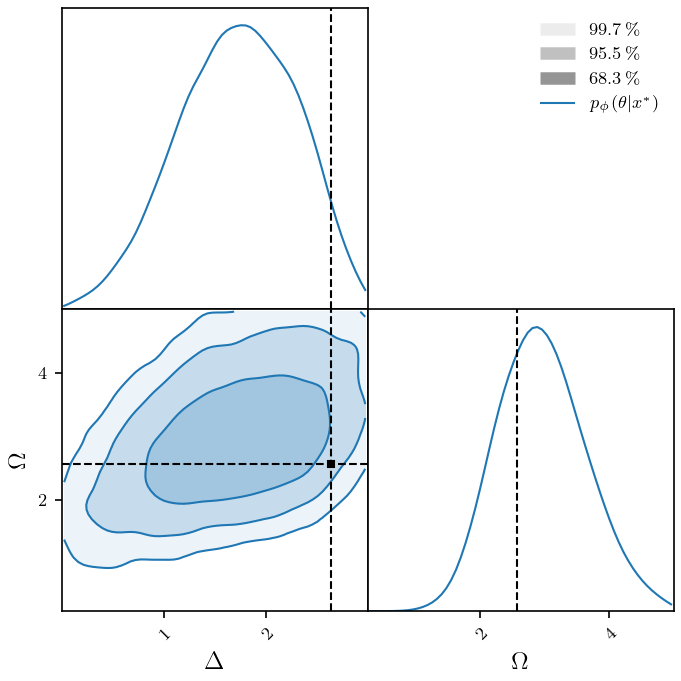

In [218]:
LABELS = [r"$\Delta$", r"$\Omega$"]

fig = corner(
    samples,
    smooth=2,
    domain=(LOWER, UPPER),
    labels=LABELS,
    legend=r"$p_\phi(\theta | x^*)$",
    figsize=(4.8, 4.8),
)

mark_point(fig, theta_star)

## Expected Coverage

The expected coverage is the fraction of the 95% credible intervals that contain the true value of the parameter. We can compute this by sampling from the posterior and checking if the true value is within the 95% credible interval.
We use this `lampe` tutorial as example [https://lampe.readthedocs.io/stable/tutorials/coverage.html#id1](https://lampe.readthedocs.io/stable/tutorials/coverage.html#id1)

It is expensive to sample from the posterior for each pair in the validation set. We only select a subset, but the coverage is better with more pairs.

In [223]:
from lampe.diagnostics import expected_coverage_mc

levels, coverages = expected_coverage_mc(
    posterior=estimator.flow,
    pairs=((preprocess(theta), x) for theta, x in islice(dataset,100)),
    n=2**10,
)

100pair [01:26,  1.16pair/s]


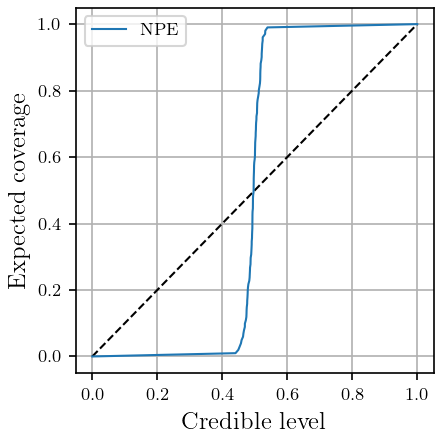

In [224]:
from lampe.plots import coverage_plot

fig = coverage_plot(levels, coverages, legend="NPE")

Being below the diagonal means having an estimator of the posterior that is overconfident. This can happen for many reasons, such has overfitting on training data.

## Embedding network

We can pre-process the trajectories of 48 jumps and extract a lower-dimensional summary statistic using an embedding network.

In our case we can use an embedding network that is manifestly permutation invariant, such as DeepSets.

In [148]:
import torch
import torch.nn as nn


class DeepSet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DeepSet, self).__init__()
        self.phi = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.rho = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        # x is expected to be of shape (batch_size, set_size, input_dim)
        # Check if x has only (batch_size, set_size)
        if x.dim() == 2:
            x = x.unsqueeze(2)
        x = self.phi(x)  # Apply phi to each element in the set
        x = torch.sum(x, dim=1)  # Sum over the set dimension
        x = self.rho(x)  # Apply rho to the aggregated set
        return x.squeeze(-1)


In [149]:
ds = DeepSet(1, 128, 1)  # input_dim is the dimension of a single tau in the trajectory, which is a scalar

In [150]:
x_star = torch.tensor(taus[1_000_000], dtype=torch.float32).expand(1,-1)  # add batch dim with expand

x_star 

tensor([[ 4.6224,  1.6125,  0.4822,  5.1973,  0.6946,  1.8963,  0.7802,  5.8742,
          0.8447,  0.7505,  1.2066,  3.1809,  3.0349,  4.8916,  0.3910,  0.2404,
          1.4983,  4.0210,  3.3411,  0.3831,  1.9232,  1.6406,  2.8031,  1.7358,
          1.3164,  0.4314,  0.3234,  4.7922,  1.7255,  0.5044,  5.7379,  1.4459,
          0.4601,  0.2455,  0.7604,  3.2227, 16.1689,  2.4234,  1.5576,  3.7224,
          0.6961,  1.6009, 10.1862,  5.1436,  0.5082,  4.0168,  2.6961,  0.4681]])

In [151]:
ds(x_star)  # see that output_dim is retained


tensor([-9.4014], grad_fn=<SqueezeBackward1>)

Create the NPE estimator including the embedding network

In [198]:
class NPEWithEmbedding(nn.Module):

    def __init__(self, theta_dim, feature_dim):
        super().__init__()

        self.npe = NPE(
            theta_dim,
            feature_dim,
            build=zuko.flows.NSF,
            hidden_features=[64] * 3,
            activation=nn.ELU,
        )
        self.embedding = DeepSet(1, 64, feature_dim)

    def forward(self, theta: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return self.npe(theta, self.embedding(x))

    def flow(self, x: torch.Tensor):  # -> Distribution
        return self.npe.flow(self.embedding(x))

In [158]:
feature_dim = 1
em_est = NPEWithEmbedding(theta_dim, feature_dim)

In [154]:
em_est

NPEWithEmbedding(
  (npe): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [0, 1]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=4, out_features=128, bias=True)
            (1): ELU(alpha=1.0)
            (2): MaskedLinear(in_features=128, out_features=128, bias=True)
            (3): ELU(alpha=1.0)
            (4): MaskedLinear(in_features=128, out_features=128, bias=True)
            (5): ELU(alpha=1.0)
            (6): MaskedLinear(in_features=128, out_features=46, bias=True)
          )
        )
        (1): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [1, 0]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=4, out_features=128, bias=True)
            (1): ELU(alpha=1.0)
            (2): MaskedLinear(in_features=128, out_features=128, bias=True)
            

In [170]:
em_est(torch.randn(1, theta_dim), torch.randn(1, x_dim))

tensor([-26.7748], grad_fn=<AddBackward0>)

Training

In [162]:
loss = NPELoss(em_est)

em_est.train()

optimizer = optim.Adam(em_est.parameters(), lr=1e-3)
step = GDStep(optimizer, clip=1.0)

for epoch in (bar := trange(15, unit="epoch")):
    train_losses = []
    val_losses = []

    for theta, x in dataset:
        train_losses.append(step(loss(theta, x)))

    for theta, x in valid_dataset:
        val_losses.append(loss(theta, x))

    bar.set_postfix(
        train_loss=torch.stack(train_losses).mean().item(),
        val_loss=torch.stack(val_losses).mean().item()
    )

100%|██████████| 15/15 [08:37<00:00, 34.51s/epoch, train_loss=-.0243, val_loss=12.4]


In [174]:
theta_star = torch.tensor(params[2_000_000], dtype=torch.float32).unsqueeze(0)
x_star = torch.tensor(taus[2_000_000], dtype=torch.float32).unsqueeze(0)

In [175]:
em_est.eval()

with torch.no_grad():
    samples = em_est.flow(x_star).sample((2**16,))

In [176]:
samples.shape

torch.Size([65536, 1, 2])

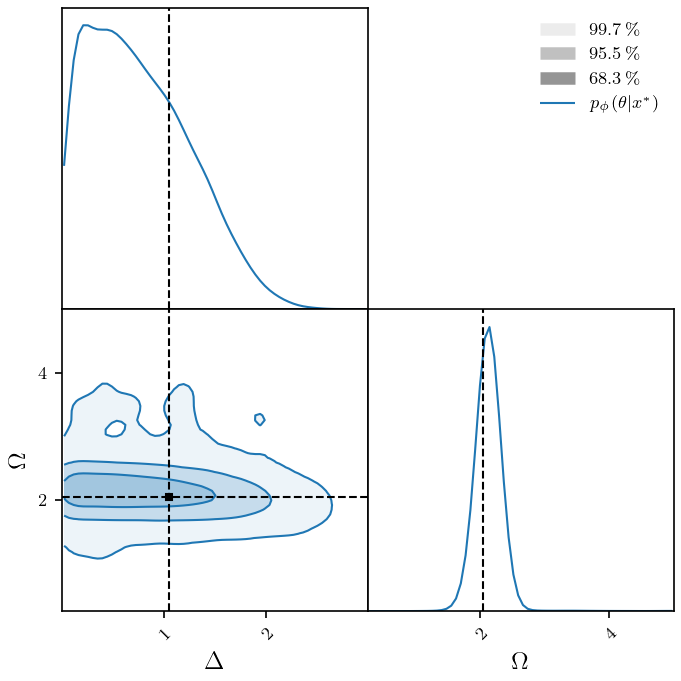

In [177]:
LOWER = torch.tensor([0.0, 0.25])
UPPER = torch.tensor([3.0, 5.0])
LABELS = [r"$\Delta$", r"$\Omega$"]

fig = corner(
    samples.squeeze(),
    smooth=2,
    domain=(LOWER, UPPER),
    labels=LABELS,
    legend=r"$p_\phi(\theta | x^*)$",
    figsize=(4.8, 4.8),
)

mark_point(fig, theta_star[0])